Dataset shape: (12000, 30)
Columns: ['id', 'num01', 'num02', 'num03', 'num04', 'num05', 'num06', 'num07', 'num08', 'num09', 'num10', 'num11', 'num12', 'num13', 'num14', 'num15', 'num16', 'num17', 'num18', 'num19', 'num20', 'num21', 'num22', 'num23', 'num24', 'cat_contract', 'cat_region', 'cat_payment', 'tenure_months', 'target']

Target distribution:
target
0    8119
1    3881
Name: count, dtype: int64

Class proportions:
target
0    0.676583
1    0.323417
Name: proportion, dtype: float64


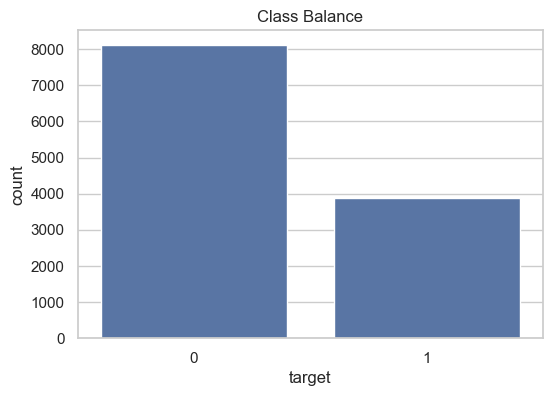


Features: 28
Target classes: [0 1]

Train size: 9600, Test size: 2400
Best params for DecisionTree: {'max_depth': 7, 'min_samples_split': 2}
Best params for RandomForest: {'max_depth': 7, 'n_estimators': 50}
Best params for GradientBoosting: {'learning_rate': 0.1, 'n_estimators': 100}

=== Dummy ===
              precision    recall  f1-score   support

           0       0.68      1.00      0.81      1624
           1       0.00      0.00      0.00       776

    accuracy                           0.68      2400
   macro avg       0.34      0.50      0.40      2400
weighted avg       0.46      0.68      0.55      2400


=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1624
           1       0.78      0.65      0.71       776

    accuracy                           0.83      2400
   macro avg       0.81      0.78      0.79      2400
weighted avg       0.82      0.83      0.82      2400


=== DecisionTre

c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Anna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

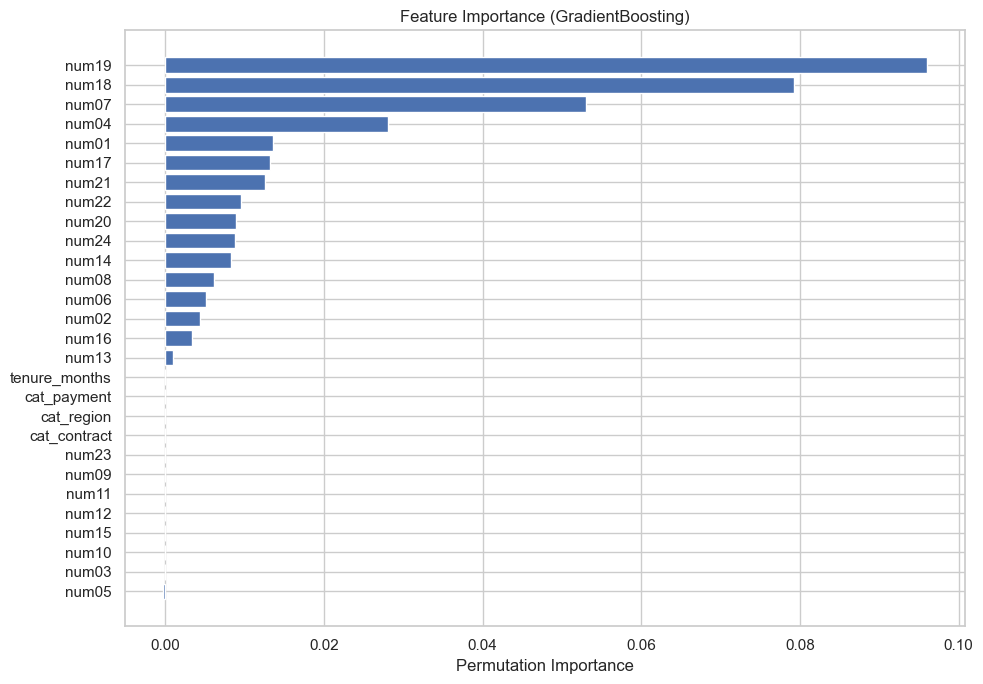


✅ Artifacts saved:
   - artifacts/model.pkl
   - artifacts/metrics.json
   - artifacts/figures/class_balance.png
   - artifacts/figures/permutation_importance.png


In [4]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance

import joblib
import json
import os

# Set plotting style
plt.rcParams['figure.figsize'] = (8, 5)
sns.set(style="whitegrid")

# 1. Load data
df = pd.read_csv("S06-hw-dataset-01.csv")
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))

# 2. EDA and class balance
print("\nTarget distribution:")
print(df['target'].value_counts())
print("\nClass proportions:")
print(df['target'].value_counts(normalize=True))

# Create artifacts directory
os.makedirs("artifacts/figures", exist_ok=True)

# Plot class balance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target')
plt.title("Class Balance")
plt.savefig("artifacts/figures/class_balance.png", dpi=150, bbox_inches='tight')
plt.show()

# 3. Prepare features and target
X = df.drop(columns=['id', 'target'])
y = df['target']

print(f"\nFeatures: {X.shape[1]}")
print(f"Target classes: {np.unique(y)}")

# 4. Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# 5. Baseline models
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# 6. Train advanced models with hyperparameter tuning
# Decision Tree
tree = DecisionTreeClassifier(random_state=42)
tree_params = {'max_depth': [3, 5, 7], 'min_samples_split': [2, 5, 10]}
tree_cv = GridSearchCV(tree, tree_params, cv=5, scoring='f1')
tree_cv.fit(X_train, y_train)
print("Best params for DecisionTree:", tree_cv.best_params_)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf_params = {'n_estimators': [50, 100], 'max_depth': [5, 7]}
rf_cv = GridSearchCV(rf, rf_params, cv=5, scoring='f1')
rf_cv.fit(X_train, y_train)
print("Best params for RandomForest:", rf_cv.best_params_)

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb_params = {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1]}
gb_cv = GridSearchCV(gb, gb_params, cv=5, scoring='f1')
gb_cv.fit(X_train, y_train)
print("Best params for GradientBoosting:", gb_cv.best_params_)

# 7. Evaluate all models on test set
models = {
    "Dummy": dummy,
    "LogisticRegression": lr,
    "DecisionTree": tree_cv.best_estimator_,
    "RandomForest": rf_cv.best_estimator_,
    "GradientBoosting": gb_cv.best_estimator_
}

metrics = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) if hasattr(model, "predict_proba") else None
    
    metrics[name] = {
        "accuracy": round(acc, 4),
        "f1": round(f1, 4),
        "roc_auc": round(auc, 4) if auc is not None else None
    }
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))

# 8. Interpret best model (by F1)
best_model_name = max(metrics, key=lambda k: metrics[k]['f1'])
best_model = models[best_model_name]
print(f"\n🏆 Best model by F1: {best_model_name} (F1 = {metrics[best_model_name]['f1']})")

# Permutation importance
perm_imp = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_imp.importances_mean.argsort()[::-1]

plt.figure(figsize=(10, max(6, len(X.columns) * 0.25)))
plt.barh(X.columns[sorted_idx], perm_imp.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title(f"Feature Importance ({best_model_name})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("artifacts/figures/permutation_importance.png", dpi=150)
plt.show()

# 9. Save artifacts
joblib.dump(best_model, "artifacts/model.pkl")
with open("artifacts/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("\n✅ Artifacts saved:")
print("   - artifacts/model.pkl")
print("   - artifacts/metrics.json")
print("   - artifacts/figures/class_balance.png")
print("   - artifacts/figures/permutation_importance.png")